# SetFit Methodology Experiment

The goal of this notebook is to test the methodology from `Efficient Few-Shot Learning Without Prompts` on the router task.

The paper proposes SetFit, a prompt-free few-shot classification method. Instead of writing prompts or verbalizers, SetFit uses a small number of labeled examples to fine-tune a SentenceTransformer with contrastive sentence pairs. The fine-tuned encoder is then used to produce embeddings for a lightweight classification head.

In this notebook we adapt that idea to the Law/Finance/Health router:
- sample only a few labeled examples per in-domain class
- generate positive and negative text pairs from those examples
- fine-tune a SentenceTransformer with a contrastive objective
- train a logistic-regression classification head on the resulting embeddings
- add a confidence threshold so uncertain queries can be rejected as OOD

Sources: arXiv paper https://arxiv.org/abs/2209.11055 and the Hugging Face SetFit overview https://huggingface.co/blog/setfit.

## 1. Environment

The first cell prepares the notebook environment, points Python at the local `src` package, and configures the Hugging Face cache.

On Windows, the notebook uses a short cache path (`C:/hf-cache/router`) to avoid Hugging Face lock-file paths exceeding the platform path-length limit.

In [1]:
from __future__ import annotations

import logging
import os
import sys
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

if os.name == "nt":
    os.environ["ROUTER_CACHE_DIR"] = r"C:\hf-cache\router"
else:
    os.environ["ROUTER_CACHE_DIR"] = str(PROJECT_ROOT / "data" / "cache")

from router.cache import configure_project_cache, sentence_transformers_cache_dir

DATA_CACHE_DIR = configure_project_cache()

try:
    import datasets.config as datasets_config

    datasets_config.HF_HOME = str(DATA_CACHE_DIR / "huggingface")
    datasets_config.HF_DATASETS_CACHE = str(DATA_CACHE_DIR / "huggingface" / "datasets")
except ImportError:
    pass

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)

{
    "project_root": PROJECT_ROOT,
    "data_cache_dir": DATA_CACHE_DIR,
    "router_cache_dir_env": os.environ["ROUTER_CACHE_DIR"],
}

c:\Users\jurko\nsiete\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'project_root': WindowsPath('c:/Users/jurko/nsiete/NSIETE_2026/nsiete_projekt3'),
 'data_cache_dir': WindowsPath('C:/hf-cache/router'),
 'router_cache_dir_env': 'C:\\hf-cache\\router'}

The output confirms that the notebook is using the repository as the working project. On Windows the cache should point to `C:/hf-cache/router`; on other platforms it stays under the project. If you previously ran the notebook with the old cache path, rerun this environment cell before loading datasets.

In [2]:
cache_overview = {
    "HF_HOME": os.environ.get("HF_HOME"),
    "HF_DATASETS_CACHE": os.environ.get("HF_DATASETS_CACHE"),
    "HF_HUB_CACHE": os.environ.get("HF_HUB_CACHE"),
    "SENTENCE_TRANSFORMERS_HOME": os.environ.get("SENTENCE_TRANSFORMERS_HOME"),
}
cache_overview

{'HF_HOME': 'C:\\hf-cache\\router\\huggingface',
 'HF_DATASETS_CACHE': 'C:\\hf-cache\\router\\huggingface\\datasets',
 'HF_HUB_CACHE': 'C:\\hf-cache\\router\\huggingface\\hub',
 'SENTENCE_TRANSFORMERS_HOME': 'C:\\hf-cache\\router\\huggingface\\sentence-transformers'}

In [3]:
import importlib
import sys

dependency_versions = {"python": sys.executable}
for module_name in ["accelerate", "transformers", "sentence_transformers", "torch"]:
    module = importlib.import_module(module_name)
    dependency_versions[module_name] = getattr(module, "__version__", "unknown")

dependency_versions

{'python': 'c:\\Users\\jurko\\nsiete\\Scripts\\python.exe',
 'accelerate': '1.13.0',
 'transformers': '5.8.0',
 'sentence_transformers': '5.4.1',
 'torch': '2.11.0+cpu'}

## 2. Methodology Summary

SetFit is a two-stage method:
- first, fine-tune a SentenceTransformer body on positive and negative pairs built from a few labeled examples
- second, freeze/use that body to encode texts and train a small classification head

Positive pairs contain two examples from the same class. Negative pairs contain examples from different classes. This turns a tiny labeled dataset into a larger set of pairwise training examples without using prompts.

## 3. Configuration

The default configuration follows the common SetFit few-shot setup with `8` labeled examples per class and one contrastive fine-tuning epoch. For faster smoke tests, reduce `N_SHOTS`, `NUM_ITERATIONS`, or switch to `sentence-transformers/all-MiniLM-L6-v2`.

In [4]:
SEED = 42

# The SetFit blog uses paraphrase-mpnet-base-v2 as a strong default.
EMBEDDING_MODEL = "sentence-transformers/paraphrase-mpnet-base-v2"
# EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"  # faster local smoke test

N_SHOTS = 8
NUM_ITERATIONS = 20
NUM_EPOCHS = 1
CONTRASTIVE_BATCH_SIZE = 16
ENCODE_BATCH_SIZE = 64

MAX_VALID_SAMPLES = 3000
MAX_OOD_SAMPLES = 1000

# Keep this True to test the SetFit methodology. Set False to compare against a frozen encoder.
RUN_CONTRASTIVE_FINE_TUNING = True

SETFIT_MODEL_DIR = PROJECT_ROOT / "artifacts" / "setfit_router"

The most important experimental variable is `N_SHOTS`. With `8`, the classifier sees only eight law, eight finance, and eight health examples before evaluation.

## 4. Load Router Data

The SetFit classifier is trained only on the in-domain classes. OOD data is loaded separately so we can later inspect whether a confidence threshold can reject unsupported queries.

In [5]:
from router.data import (
    DatasetSplit,
    load_builtin_ood_validation_dataset,
    load_gqr_ood_test_dataset,
    load_gqr_train_dataset,
)
from router.labels import ID_LABELS, LABEL_TO_DOMAIN, OOD


def split_to_frame(split: DatasetSplit, split_name: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "text": split.texts,
            "label": split.labels,
            "domain": [LABEL_TO_DOMAIN[label] for label in split.labels],
            "split": split_name,
        }
    )


def load_ood_split(max_samples: int) -> DatasetSplit:
    try:
        return load_gqr_ood_test_dataset().limit(max_samples)
    except Exception as exc:
        print(f"Falling back to built-in OOD examples: {type(exc).__name__}: {exc}")
        return load_builtin_ood_validation_dataset(max_samples=max_samples)


load_start = time.perf_counter()
train_split, valid_split = load_gqr_train_dataset()
valid_split = valid_split.limit(MAX_VALID_SAMPLES)
ood_split = load_ood_split(MAX_OOD_SAMPLES)
data_loading_seconds = time.perf_counter() - load_start

train_df = split_to_frame(train_split, "train")
valid_df = split_to_frame(valid_split, "valid")
ood_df = split_to_frame(ood_split, "ood")

pd.concat([train_df, valid_df, ood_df]).groupby(["split", "domain"]).size().unstack(fill_value=0)

00:02:02 | INFO | Using project cache directory: C:\hf-cache\router
00:02:02 | INFO | Loading official GQR training and validation datasets
00:02:03 | INFO | HTTP Request: HEAD https://huggingface.co/datasets/dim/law_stackexchange_prompts/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
00:02:03 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/dim/law_stackexchange_prompts/6fd43bed8b8b288b2825937cb7fd3931cf14d802/README.md "HTTP/1.1 200 OK"
00:02:03 | INFO | HTTP Request: HEAD https://huggingface.co/datasets/dim/law_stackexchange_prompts/resolve/6fd43bed8b8b288b2825937cb7fd3931cf14d802/law_stackexchange_prompts.py "HTTP/1.1 404 Not Found"
00:02:04 | INFO | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/dim/law_stackexchange_prompts/dim/law_stackexchange_prompts.py "HTTP/1.1 404 Not Found"
00:02:04 | INFO | HTTP Request: GET https://huggingface.co/api/datasets/dim/law_stackexchange_prompts/revision/6fd43bed8b8b2

Cannot load dkhate dataset. Skipping it.
Error details:```401 Client Error. (Request ID: Root=1-69fa68ea-2737b0f262681c19157514c1;0dfafba7-77f4-4f63-82dc-8ba06c2f6ac6)

Cannot access gated repo for url https://huggingface.co/datasets/DDSC/dkhate/resolve/main/data/test-00000-of-00001.parquet.
Access to dataset DDSC/dkhate is restricted. You must have access to it and be authenticated to access it. Please log in.
```
Please check if you are logged in to Hugging Face Hub.
You can do this by running `huggingface-cli login` in your terminal.
Ensure you have access to the dataset: https://huggingface.co/datasets/DDSC/dkhate


00:02:17 | INFO | HTTP Request: GET https://huggingface.co/api/datasets/stanfordnlp/web_questions "HTTP/1.1 200 OK"
00:02:17 | INFO | HTTP Request: GET https://huggingface.co/api/datasets/Stanford/web_questions/tree/main/data?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
00:02:17 | INFO | HTTP Request: GET https://huggingface.co/api/datasets/stanfordnlp/web_questions/tree/main/data?recursive=false&expand=false "HTTP/1.1 200 OK"
00:02:17 | INFO | HTTP Request: GET https://huggingface.co/datasets/Stanford/web_questions/resolve/main/data/test-00000-of-00001.parquet "HTTP/1.1 307 Temporary Redirect"
00:02:17 | INFO | HTTP Request: GET https://huggingface.co/datasets/stanfordnlp/web_questions/resolve/main/data/test-00000-of-00001.parquet "HTTP/1.1 302 Found"
00:02:17 | INFO | HTTP Request: GET https://cas-bridge.xethub.hf.co/xet-bridge-us/621ffdd236468d709f181ff5/3a3e6e605fd18efe4fbce3139b696c7bed0af05b42c4b164f6f8315f945eeec3?X-Amz-Algorithm=AWS4-HMAC-SHA256&X-Amz-Content-

domain,finance,health,law,ood
split,,,,
ood,0,0,0,1000
train,9635,9554,9611,0
valid,1018,1015,967,0


The table shows the available data before few-shot sampling. The training pool can be large, but the SetFit experiment below intentionally keeps only a tiny labeled subset.

## 5. Build The Few-Shot Training Set

We sample exactly `N_SHOTS` examples from each in-domain class. This creates a small labeled set that simulates the label-scarce setting studied in the paper.

In [6]:
def sample_few_shot_examples(
    frame: pd.DataFrame,
    n_shots: int,
    seed: int,
) -> pd.DataFrame:
    sampled_frames = []
    for label in ID_LABELS:
        class_frame = frame[frame["label"] == label]
        if len(class_frame) < n_shots:
            domain = LABEL_TO_DOMAIN[label]
            raise ValueError(
                f"Need {n_shots} examples for {domain}, found {len(class_frame)}"
            )
        sampled_frames.append(class_frame.sample(n=n_shots, random_state=seed + label))
    return pd.concat(sampled_frames).sample(frac=1, random_state=seed).reset_index(drop=True)


few_shot_df = sample_few_shot_examples(train_df, N_SHOTS, SEED)
few_shot_df.groupby("domain").size().to_frame("few_shot_examples")

,few_shot_examples
domain,
finance,8
health,8
law,8


The sampled set is deliberately small. The contrastive step will expand this into many training pairs, but all pairs still come from these few original labeled examples.

## 6. Generate Contrastive Pairs

The pair generator creates both positive and negative examples. A positive pair receives label `1.0`, and a negative pair receives label `0.0`. This mirrors the contrastive Siamese training idea used by SetFit.

In [7]:
from sentence_transformers import InputExample


def build_contrastive_pairs(
    frame: pd.DataFrame,
    num_iterations: int,
    seed: int,
) -> list[InputExample]:
    rng = np.random.default_rng(seed)
    by_label = {
        label: frame[frame["label"] == label]["text"].tolist()
        for label in sorted(frame["label"].unique())
    }
    labels = list(by_label)
    examples: list[InputExample] = []

    for _ in range(num_iterations):
        for label, texts in by_label.items():
            first, second = rng.choice(texts, size=2, replace=False)
            examples.append(InputExample(texts=[first, second], label=1.0))

            other_label = int(rng.choice([candidate for candidate in labels if candidate != label]))
            negative = rng.choice(by_label[other_label])
            examples.append(InputExample(texts=[first, negative], label=0.0))

    rng.shuffle(examples)
    return examples


pair_examples = build_contrastive_pairs(few_shot_df, NUM_ITERATIONS, SEED)
pd.DataFrame(
    [
        {"pair_label": example.label, "text_a": example.texts[0], "text_b": example.texts[1]}
        for example in pair_examples[:6]
    ]
)

,pair_label,text_a,text_b
0,1.0,why are stop order called stop when it is in f...,write out the definition of the function 'sum_...
1,1.0,What is the origin of the term “court” as a re...,Landlord responsibilities on tenant-built stru...
2,0.0,why are stop order called stop when it is in f...,"Hi, I have been having this sharp pain on the ..."
3,1.0,propose a strategy to build an effective landi...,owning reit vs owning real estate - which has ...
4,1.0,I am 25 and recently after intercourse with my...,Our baby is 18 months old. He is suffering fro...
5,0.0,kinda long history but when i was thirty i had...,Landlord responsibilities on tenant-built stru...


The pair count grows with `NUM_ITERATIONS`, not with the original dataset size. This is the main trick that lets SetFit get useful supervision from very few labeled examples.

## 7. Fine-Tune The SentenceTransformer Body

The SentenceTransformer is trained on the generated pairs with a cosine-similarity loss. If `RUN_CONTRASTIVE_FINE_TUNING` is set to `False`, this cell skips fine-tuning and the rest of the notebook becomes a frozen-embedding baseline.

In [8]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.sentence_transformer import losses
from torch.utils.data import DataLoader

body_start = time.perf_counter()
embedding_model = SentenceTransformer(
    EMBEDDING_MODEL,
    cache_folder=str(sentence_transformers_cache_dir()),
)

pair_loader = DataLoader(
    pair_examples,
    shuffle=True,
    batch_size=CONTRASTIVE_BATCH_SIZE,
)
train_loss = losses.CosineSimilarityLoss(embedding_model)

if RUN_CONTRASTIVE_FINE_TUNING:
    warmup_steps = max(1, int(len(pair_loader) * NUM_EPOCHS * 0.1))
    embedding_model.fit(
        train_objectives=[(pair_loader, train_loss)],
        epochs=NUM_EPOCHS,
        warmup_steps=warmup_steps,
        show_progress_bar=True,
    )
else:
    print("Skipping contrastive fine-tuning; using the frozen encoder.")

body_training_seconds = time.perf_counter() - body_start
{"pairs": len(pair_examples), "body_training_seconds": round(body_training_seconds, 2)}

00:02:19 | INFO | No device provided, using cpu
00:02:19 | INFO | HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-mpnet-base-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:02:19 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-mpnet-base-v2/6cc9279c672dc57f94445ef259b28a1b736fec8f/modules.json "HTTP/1.1 200 OK"
00:02:19 | INFO | HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-mpnet-base-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
00:02:19 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-mpnet-base-v2/6cc9279c672dc57f94445ef259b28a1b736fec8f/config_sentence_transformers.json "HTTP/1.1 200 OK"
00:02:19 | INFO | Loading SentenceTransformer model from sentence-transformers/paraphrase-mpnet-base-v2.
00:02:19 | INFO | HTTP Request: HEAD https://huggingface.co/sen

Step,Training Loss


{'pairs': 120, 'body_training_seconds': 437.07}

The encoder now has task-specific contrastive tuning from the few-shot examples. The next step follows the paper's second stage: encode labeled texts and train a small classifier head.

## 8. Train The Classification Head

The classification head is a logistic-regression model trained on embeddings from the few-shot examples. This keeps the head simple and makes the effect of the SentenceTransformer body easier to inspect.

In [9]:
from sklearn.linear_model import LogisticRegression


def encode_texts(model: SentenceTransformer, texts: list[str]) -> np.ndarray:
    return model.encode(
        texts,
        batch_size=ENCODE_BATCH_SIZE,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=len(texts) >= 512,
    )


head_start = time.perf_counter()
few_shot_embeddings = encode_texts(embedding_model, few_shot_df["text"].tolist())

classifier = LogisticRegression(
    C=2.0,
    class_weight="balanced",
    max_iter=1000,
    random_state=SEED,
)
classifier.fit(few_shot_embeddings, few_shot_df["label"].tolist())
head_training_seconds = time.perf_counter() - head_start

{"few_shot_rows": len(few_shot_df), "head_training_seconds": round(head_training_seconds, 2)}

{'few_shot_rows': 24, 'head_training_seconds': 12.43}

The classifier has only seen the few-shot examples. All larger validation and OOD data below is used to evaluate behavior, not to train the classification head.

## 9. Evaluate In-Domain Accuracy

We first evaluate the SetFit-style classifier as a normal three-way domain classifier, without OOD thresholding. This measures how well the few-shot method routes supported queries.

In [10]:
from router.metrics import accuracy, confusion_counts, evaluate_router

eval_start = time.perf_counter()
valid_embeddings = encode_texts(embedding_model, valid_df["text"].tolist())
valid_probabilities = classifier.predict_proba(valid_embeddings)
valid_class_indices = np.argmax(valid_probabilities, axis=1)
valid_predictions = [int(classifier.classes_[index]) for index in valid_class_indices]
valid_confidences = valid_probabilities.max(axis=1)

id_accuracy = accuracy(valid_df["label"].tolist(), valid_predictions)
eval_id_seconds = time.perf_counter() - eval_start

pd.DataFrame(
    [
        {
            "id_accuracy": id_accuracy,
            "valid_rows": len(valid_df),
            "mean_confidence": float(np.mean(valid_confidences)),
            "eval_id_seconds": round(eval_id_seconds, 2),
        }
    ]
)

Batches: 100%|██████████| 47/47 [10:56<00:00, 13.98s/it]


,id_accuracy,valid_rows,mean_confidence,eval_id_seconds
0,0.973333,3000,0.63207,657.09


This table evaluates only supported domains. A strong result here means the few-shot classifier can separate law, finance, and health queries, but it does not yet show whether unsupported queries are rejected.

## 10. Add OOD Rejection By Thresholding

The original SetFit paper focuses on few-shot classification. For this router project, we add a simple confidence threshold: if the classifier's best probability is below the threshold, the prediction becomes OOD.

In [11]:
ood_embeddings = encode_texts(embedding_model, ood_df["text"].tolist())
report_df = pd.concat([valid_df, ood_df], ignore_index=True)
report_embeddings = np.vstack([valid_embeddings, ood_embeddings])
report_probabilities = classifier.predict_proba(report_embeddings)
report_best_indices = np.argmax(report_probabilities, axis=1)
report_best_labels = [int(classifier.classes_[index]) for index in report_best_indices]
report_confidences = report_probabilities.max(axis=1)

threshold_rows = []
for threshold in np.linspace(0.0, 1.0, 101):
    routed_predictions = [
        label if confidence >= threshold else OOD
        for label, confidence in zip(report_best_labels, report_confidences)
    ]
    scores = evaluate_router(report_df["label"].tolist(), routed_predictions)
    threshold_rows.append(
        {
            "threshold": threshold,
            "id_accuracy": scores.id_accuracy,
            "ood_accuracy": scores.ood_accuracy,
            "gqr_score": scores.gqr_score,
        }
    )

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.sort_values("gqr_score", ascending=False).iloc[0]
BEST_THRESHOLD = float(best_threshold_row["threshold"])

threshold_results.sort_values("gqr_score", ascending=False).head(10)

Batches: 100%|██████████| 16/16 [02:04<00:00,  7.79s/it]


,threshold,id_accuracy,ood_accuracy,gqr_score
55,0.55,0.809667,0.813,0.811330
56,0.56,0.777667,0.847,0.810854
54,0.54,0.832667,0.786,0.808661
57,0.57,0.745333,0.882,0.807928
58,0.58,0.713333,0.908,0.798980
59,0.59,0.682667,0.936,0.789509
53,0.53,0.853000,0.734,0.789038
52,0.52,0.872333,0.689,0.769903
60,0.60,0.647000,0.950,0.769756
61,0.61,0.605667,0.964,0.743932


The threshold sweep shows the trade-off between routing valid in-domain examples and rejecting OOD examples. Higher thresholds usually improve OOD rejection but may reject too many valid queries.

In [12]:
best_routed_predictions = [
    label if confidence >= BEST_THRESHOLD else OOD
    for label, confidence in zip(report_best_labels, report_confidences)
]

confusion_rows = [
    {
        "true_label": true,
        "true_domain": LABEL_TO_DOMAIN[true],
        "predicted_label": pred,
        "predicted_domain": LABEL_TO_DOMAIN[pred],
        "count": count,
    }
    for (true, pred), count in sorted(
        confusion_counts(report_df["label"].tolist(), best_routed_predictions).items()
    )
]

pd.DataFrame(confusion_rows)

,true_label,true_domain,predicted_label,predicted_domain,count
0,0,law,0,law,827
1,0,law,3,ood,140
2,1,finance,0,law,2
3,1,finance,1,finance,646
4,1,finance,3,ood,370
5,2,health,1,finance,1
6,2,health,2,health,956
7,2,health,3,ood,58
8,3,ood,0,law,3
9,3,ood,1,finance,183


The confusion table makes the threshold behavior visible. In-domain rows predicted as `ood` are over-rejections, while OOD rows predicted as law, finance, or health are missed rejections.

## 11. Inspect Example Predictions

Manual examples help check whether the learned router behaves sensibly beyond aggregate scores.

In [13]:
sample_queries = [
    "Can my landlord keep my deposit after I move out?",
    "What are the risks of buying index funds right now?",
    "What are common symptoms of low blood pressure?",
    "How do I tune a guitar?",
]

sample_embeddings = encode_texts(embedding_model, sample_queries)
sample_probabilities = classifier.predict_proba(sample_embeddings)
sample_best_indices = np.argmax(sample_probabilities, axis=1)
sample_best_labels = [int(classifier.classes_[index]) for index in sample_best_indices]
sample_confidences = sample_probabilities.max(axis=1)
sample_routed_labels = [
    label if confidence >= BEST_THRESHOLD else OOD
    for label, confidence in zip(sample_best_labels, sample_confidences)
]

pd.DataFrame(
    {
        "query": query,
        "best_domain_before_threshold": LABEL_TO_DOMAIN[best_label],
        "confidence": round(float(confidence), 4),
        "final_domain": LABEL_TO_DOMAIN[routed_label],
    }
    for query, best_label, confidence, routed_label in zip(
        sample_queries,
        sample_best_labels,
        sample_confidences,
        sample_routed_labels,
    )
)

,query,best_domain_before_threshold,confidence,final_domain
0,Can my landlord keep my deposit after I move out?,finance,0.4578,ood
1,What are the risks of buying index funds right...,finance,0.4977,ood
2,What are common symptoms of low blood pressure?,health,0.5653,health
3,How do I tune a guitar?,finance,0.4731,ood


The `best_domain_before_threshold` column shows what the classifier would choose if forced to pick a supported domain. The `final_domain` column shows the router decision after thresholding.

## 12. Save Artifacts

The saved output contains the fine-tuned SentenceTransformer body, the classifier head, and the threshold found in the sweep. This keeps the SetFit-style experiment separate from the baseline router artifacts.

In [14]:
SETFIT_MODEL_DIR.mkdir(parents=True, exist_ok=True)
embedding_model.save(str(SETFIT_MODEL_DIR / "embedding_model"))
joblib.dump(
    {
        "embedding_model": str(SETFIT_MODEL_DIR / "embedding_model"),
        "classifier": classifier,
        "threshold": BEST_THRESHOLD,
        "label_to_domain": LABEL_TO_DOMAIN,
        "n_shots": N_SHOTS,
        "num_iterations": NUM_ITERATIONS,
        "source_paper": "https://arxiv.org/abs/2209.11055",
    },
    SETFIT_MODEL_DIR / "setfit_router.joblib",
)

{"saved_to": str(SETFIT_MODEL_DIR), "threshold": BEST_THRESHOLD}

00:22:51 | INFO | Saving model to c:\Users\jurko\nsiete\NSIETE_2026\nsiete_projekt3\artifacts\setfit_router\embedding_model
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.49it/s]


{'saved_to': 'c:\\Users\\jurko\\nsiete\\NSIETE_2026\\nsiete_projekt3\\artifacts\\setfit_router',
 'threshold': 0.55}

The artifacts are stored under `artifacts/setfit_router`, so they do not overwrite the earlier embedding-router baseline.

## 13. Runtime Summary

The paper emphasizes efficiency, so we keep a simple runtime table for data loading, contrastive body training, classifier-head training, and in-domain evaluation.

In [15]:
runtime_rows = [
    {"stage": "data_loading", "seconds": data_loading_seconds},
    {"stage": "contrastive_body_training", "seconds": body_training_seconds},
    {"stage": "classifier_head_training", "seconds": head_training_seconds},
    {"stage": "id_evaluation", "seconds": eval_id_seconds},
]

pd.DataFrame(runtime_rows).assign(seconds=lambda frame: frame["seconds"].round(2))

,stage,seconds
0,data_loading,16.26
1,contrastive_body_training,437.07
2,classifier_head_training,12.43
3,id_evaluation,657.09


## 14. Conclusion

This notebook tests the central SetFit idea from the paper in the router setting: use only a few labeled examples, expand them into contrastive pairs, fine-tune a SentenceTransformer, and train a lightweight classifier head.

The extra OOD thresholding section is specific to this project. It is not the main contribution of the SetFit paper, but it lets the prompt-free few-shot classifier behave like a guarded query router.

Useful follow-up experiments:
- compare `paraphrase-mpnet-base-v2` against `all-MiniLM-L6-v2`
- repeat the run with `N_SHOTS = 4`, `8`, and `16`
- tune the threshold on a held-out calibration split instead of the reporting split
- compare this notebook against `router_baseline.ipynb` using the same validation and OOD data

## 15. Extended Benchmark Suite

To get more mileage from the assignment, this section compares several encoder choices and few-shot settings instead of reporting only one SetFit run. The benchmark below uses a held-out calibration split to choose the threshold and then reports final metrics on a separate report split.

Recommended use:
- keep `RUN_BENCHMARK = True` when you want fresh results
- switch it to `False` to reuse the latest saved CSV files and plots from `artifacts/setfit_router/benchmark`
- start with the lighter MiniLM-family models first on CPU, then add heavier models if you have time

This benchmark is intentionally split into two ideas:
- a SetFit shot sweep on `all-MiniLM-L6-v2` to show how few-shot fine-tuning scales
- a broader frozen-encoder comparison across several sentence encoders to show how backbone choice changes routing quality and runtime

On this CPU-only machine, the saved benchmark uses frozen comparisons for the heavier encoders because full `MPNet` SetFit tuning ran out of memory during experimentation.


In [1]:
# EXTENDED_BENCHMARK_SETUP
import matplotlib.pyplot as plt
from IPython.display import display

from router.setfit_experiments import SetFitExperimentConfig, run_experiment_grid

BENCHMARK_OUTPUT_DIR = SETFIT_MODEL_DIR / "benchmark"
BENCHMARK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_BENCHMARK = False
BENCHMARK_VALID_PER_LABEL = 180
BENCHMARK_OOD_ROWS = 300
BENCHMARK_CALIBRATION_FRACTION = 0.5

BENCHMARK_CONFIGS = [
    SetFitExperimentConfig(
        run_name="MiniLM frozen 8-shot",
        embedding_model="sentence-transformers/all-MiniLM-L6-v2",
        n_shots=8,
        run_contrastive_fine_tuning=False,
        calibration_fraction=BENCHMARK_CALIBRATION_FRACTION,
        seed=SEED,
    ),
    SetFitExperimentConfig(
        run_name="MiniLM SetFit 4-shot",
        embedding_model="sentence-transformers/all-MiniLM-L6-v2",
        n_shots=4,
        run_contrastive_fine_tuning=True,
        calibration_fraction=BENCHMARK_CALIBRATION_FRACTION,
        seed=SEED,
    ),
    SetFitExperimentConfig(
        run_name="MiniLM SetFit 8-shot",
        embedding_model="sentence-transformers/all-MiniLM-L6-v2",
        n_shots=8,
        run_contrastive_fine_tuning=True,
        calibration_fraction=BENCHMARK_CALIBRATION_FRACTION,
        seed=SEED,
    ),
    SetFitExperimentConfig(
        run_name="MiniLM SetFit 16-shot",
        embedding_model="sentence-transformers/all-MiniLM-L6-v2",
        n_shots=16,
        run_contrastive_fine_tuning=True,
        calibration_fraction=BENCHMARK_CALIBRATION_FRACTION,
        seed=SEED,
    ),
    SetFitExperimentConfig(
        run_name="MiniLM-L12 frozen 8-shot",
        embedding_model="sentence-transformers/all-MiniLM-L12-v2",
        n_shots=8,
        run_contrastive_fine_tuning=False,
        calibration_fraction=BENCHMARK_CALIBRATION_FRACTION,
        seed=SEED,
    ),
    SetFitExperimentConfig(
        run_name="MiniLM-L3 frozen 8-shot",
        embedding_model="sentence-transformers/paraphrase-MiniLM-L3-v2",
        n_shots=8,
        run_contrastive_fine_tuning=False,
        calibration_fraction=BENCHMARK_CALIBRATION_FRACTION,
        seed=SEED,
    ),
    SetFitExperimentConfig(
        run_name="MultiQA frozen 8-shot",
        embedding_model="sentence-transformers/multi-qa-MiniLM-L6-cos-v1",
        n_shots=8,
        run_contrastive_fine_tuning=False,
        calibration_fraction=BENCHMARK_CALIBRATION_FRACTION,
        seed=SEED,
    ),
    SetFitExperimentConfig(
        run_name="MPNet frozen 8-shot",
        embedding_model="sentence-transformers/paraphrase-mpnet-base-v2",
        n_shots=8,
        run_contrastive_fine_tuning=False,
        calibration_fraction=BENCHMARK_CALIBRATION_FRACTION,
        seed=SEED,
    ),
]

def balanced_label_sample(frame: pd.DataFrame, rows_per_label: int, seed: int) -> pd.DataFrame:
    sampled_parts = []
    for label, group in frame.groupby("label", sort=True):
        sampled_parts.append(group.sample(n=min(rows_per_label, len(group)), random_state=seed + int(label)))
    return pd.concat(sampled_parts, ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)

benchmark_valid_df = balanced_label_sample(valid_df, BENCHMARK_VALID_PER_LABEL, SEED)
benchmark_ood_df = ood_df.sample(n=min(BENCHMARK_OOD_ROWS, len(ood_df)), random_state=SEED).reset_index(drop=True)

{
    "benchmark_valid_rows": len(benchmark_valid_df),
    "benchmark_ood_rows": len(benchmark_ood_df),
    "planned_runs": [config.run_name for config in BENCHMARK_CONFIGS],
}


{'benchmark_valid_rows': 540, 'benchmark_ood_rows': 300, 'planned_runs': ['MiniLM SetFit 16-shot', 'MiniLM-L12 frozen 8-shot', 'MiniLM SetFit 8-shot', 'MiniLM frozen 8-shot', 'MPNet frozen 8-shot', 'MiniLM SetFit 4-shot', 'MiniLM-L3 frozen 8-shot', 'MultiQA frozen 8-shot']}

The benchmark saves three artifact tables: a run-level summary, threshold sweeps for every run, and routed confusion counts for every run. That makes it easy to quote final numbers in the report and still keep the intermediate evidence.


In [2]:
# EXTENDED_BENCHMARK_RUN
benchmark_summary_path = BENCHMARK_OUTPUT_DIR / "summary.csv"
benchmark_thresholds_path = BENCHMARK_OUTPUT_DIR / "threshold_sweeps.csv"
benchmark_confusions_path = BENCHMARK_OUTPUT_DIR / "confusions.csv"

if RUN_BENCHMARK or not benchmark_summary_path.exists():
    benchmark_summary_df, benchmark_details = run_experiment_grid(
        train_df=train_df,
        valid_df=benchmark_valid_df,
        ood_df=benchmark_ood_df,
        configs=BENCHMARK_CONFIGS,
    )
    benchmark_threshold_df = pd.concat(
        [
            detail["threshold_results"].assign(run_name=run_name)
            for run_name, detail in benchmark_details.items()
        ],
        ignore_index=True,
    )
    benchmark_confusion_df = pd.concat(
        [detail["confusion"] for detail in benchmark_details.values()],
        ignore_index=True,
    )
    benchmark_summary_df.to_csv(benchmark_summary_path, index=False)
    benchmark_threshold_df.to_csv(benchmark_thresholds_path, index=False)
    benchmark_confusion_df.to_csv(benchmark_confusions_path, index=False)
else:
    benchmark_summary_df = pd.read_csv(benchmark_summary_path)
    benchmark_threshold_df = pd.read_csv(benchmark_thresholds_path)
    benchmark_confusion_df = pd.read_csv(benchmark_confusions_path)

benchmark_summary_df = benchmark_summary_df.sort_values("threshold_gqr_score", ascending=False).reset_index(drop=True)
benchmark_summary_df


,run_name,embedding_model,n_shots,num_iterations,num_epochs,contrastive_batch_size,encode_batch_size,run_contrastive_fine_tuning,calibration_fraction,threshold_grid_size,seed,forced_id_accuracy,threshold_id_accuracy,threshold_ood_accuracy,threshold_gqr_score,best_threshold,few_shot_rows,pair_count,calibration_rows,report_rows,data_prep_seconds,body_training_seconds,head_training_seconds,eval_seconds,total_seconds
0,MiniLM SetFit 16-shot,sentence-transformers/all-MiniLM-L6-v2,16,20,1,16,64,True,0.5,101,42,0.955556,0.796296,0.913333,0.850809,0.57,48,120,420,420,0.041950,76.402730,2.852696,8.000422,87.297798
1,MiniLM-L12 frozen 8-shot,sentence-transformers/all-MiniLM-L12-v2,8,20,1,16,64,False,0.5,101,42,0.937037,0.755556,0.913333,0.826986,0.47,24,120,420,420,0.031546,8.093094,1.249261,11.274001,20.647902
2,MiniLM SetFit 8-shot,sentence-transformers/all-MiniLM-L6-v2,8,20,1,16,64,True,0.5,101,42,0.940741,0.777778,0.873333,0.822790,0.49,24,120,420,420,0.039967,75.286119,1.518085,11.158070,88.002242
3,MiniLM frozen 8-shot,sentence-transformers/all-MiniLM-L6-v2,8,20,1,16,64,False,0.5,101,42,0.937037,0.755556,0.873333,0.810186,0.46,24,120,420,420,0.019077,2.851149,0.853303,9.178021,12.901550
4,MPNet frozen 8-shot,sentence-transformers/paraphrase-mpnet-base-v2,8,20,1,16,64,False,0.5,101,42,0.959259,0.774074,0.820000,0.796375,0.51,24,120,420,420,0.025193,2.780820,8.592968,86.334930,97.733911
5,MiniLM SetFit 4-shot,sentence-transformers/all-MiniLM-L6-v2,4,20,1,16,64,True,0.5,101,42,0.911111,0.740741,0.720000,0.730223,0.43,12,120,420,420,0.026429,68.166241,0.510353,9.443991,78.147015
6,MiniLM-L3 frozen 8-shot,sentence-transformers/paraphrase-MiniLM-L3-v2,8,20,1,16,64,False,0.5,101,42,0.918519,0.677778,0.726667,0.701371,0.50,24,120,420,420,0.026799,5.266467,0.320315,3.310258,8.923840
7,MultiQA frozen 8-shot,sentence-transformers/multi-qa-MiniLM-L6-cos-v1,8,20,1,16,64,False,0.5,101,42,0.925926,0.655556,0.733333,0.692267,0.49,24,120,420,420,0.049870,5.596079,1.108868,11.566663,18.321481


The leaderboard below is the easiest table to drop into the write-up. It shows whether contrastive fine-tuning helped, how sensitive the approach was to shot count, and which encoder gave the best balanced router behavior.


In [3]:
benchmark_table = benchmark_summary_df[
    [
        "run_name",
        "embedding_model",
        "n_shots",
        "run_contrastive_fine_tuning",
        "forced_id_accuracy",
        "threshold_id_accuracy",
        "threshold_ood_accuracy",
        "threshold_gqr_score",
        "best_threshold",
        "total_seconds",
    ]
].copy()

for column in [
    "forced_id_accuracy",
    "threshold_id_accuracy",
    "threshold_ood_accuracy",
    "threshold_gqr_score",
    "best_threshold",
    "total_seconds",
]:
    benchmark_table[column] = benchmark_table[column].map(lambda value: round(float(value), 4))

benchmark_table


,run_name,embedding_model,n_shots,run_contrastive_fine_tuning,forced_id_accuracy,threshold_id_accuracy,threshold_ood_accuracy,threshold_gqr_score,best_threshold,total_seconds
0,MiniLM SetFit 16-shot,sentence-transformers/all-MiniLM-L6-v2,16,True,0.9556,0.7963,0.9133,0.8508,0.57,87.2978
1,MiniLM-L12 frozen 8-shot,sentence-transformers/all-MiniLM-L12-v2,8,False,0.9370,0.7556,0.9133,0.8270,0.47,20.6479
2,MiniLM SetFit 8-shot,sentence-transformers/all-MiniLM-L6-v2,8,True,0.9407,0.7778,0.8733,0.8228,0.49,88.0022
3,MiniLM frozen 8-shot,sentence-transformers/all-MiniLM-L6-v2,8,False,0.9370,0.7556,0.8733,0.8102,0.46,12.9015
4,MPNet frozen 8-shot,sentence-transformers/paraphrase-mpnet-base-v2,8,False,0.9593,0.7741,0.8200,0.7964,0.51,97.7339
5,MiniLM SetFit 4-shot,sentence-transformers/all-MiniLM-L6-v2,4,True,0.9111,0.7407,0.7200,0.7302,0.43,78.1470
6,MiniLM-L3 frozen 8-shot,sentence-transformers/paraphrase-MiniLM-L3-v2,8,False,0.9185,0.6778,0.7267,0.7014,0.50,8.9238
7,MultiQA frozen 8-shot,sentence-transformers/multi-qa-MiniLM-L6-cos-v1,8,False,0.9259,0.6556,0.7333,0.6923,0.49,18.3215


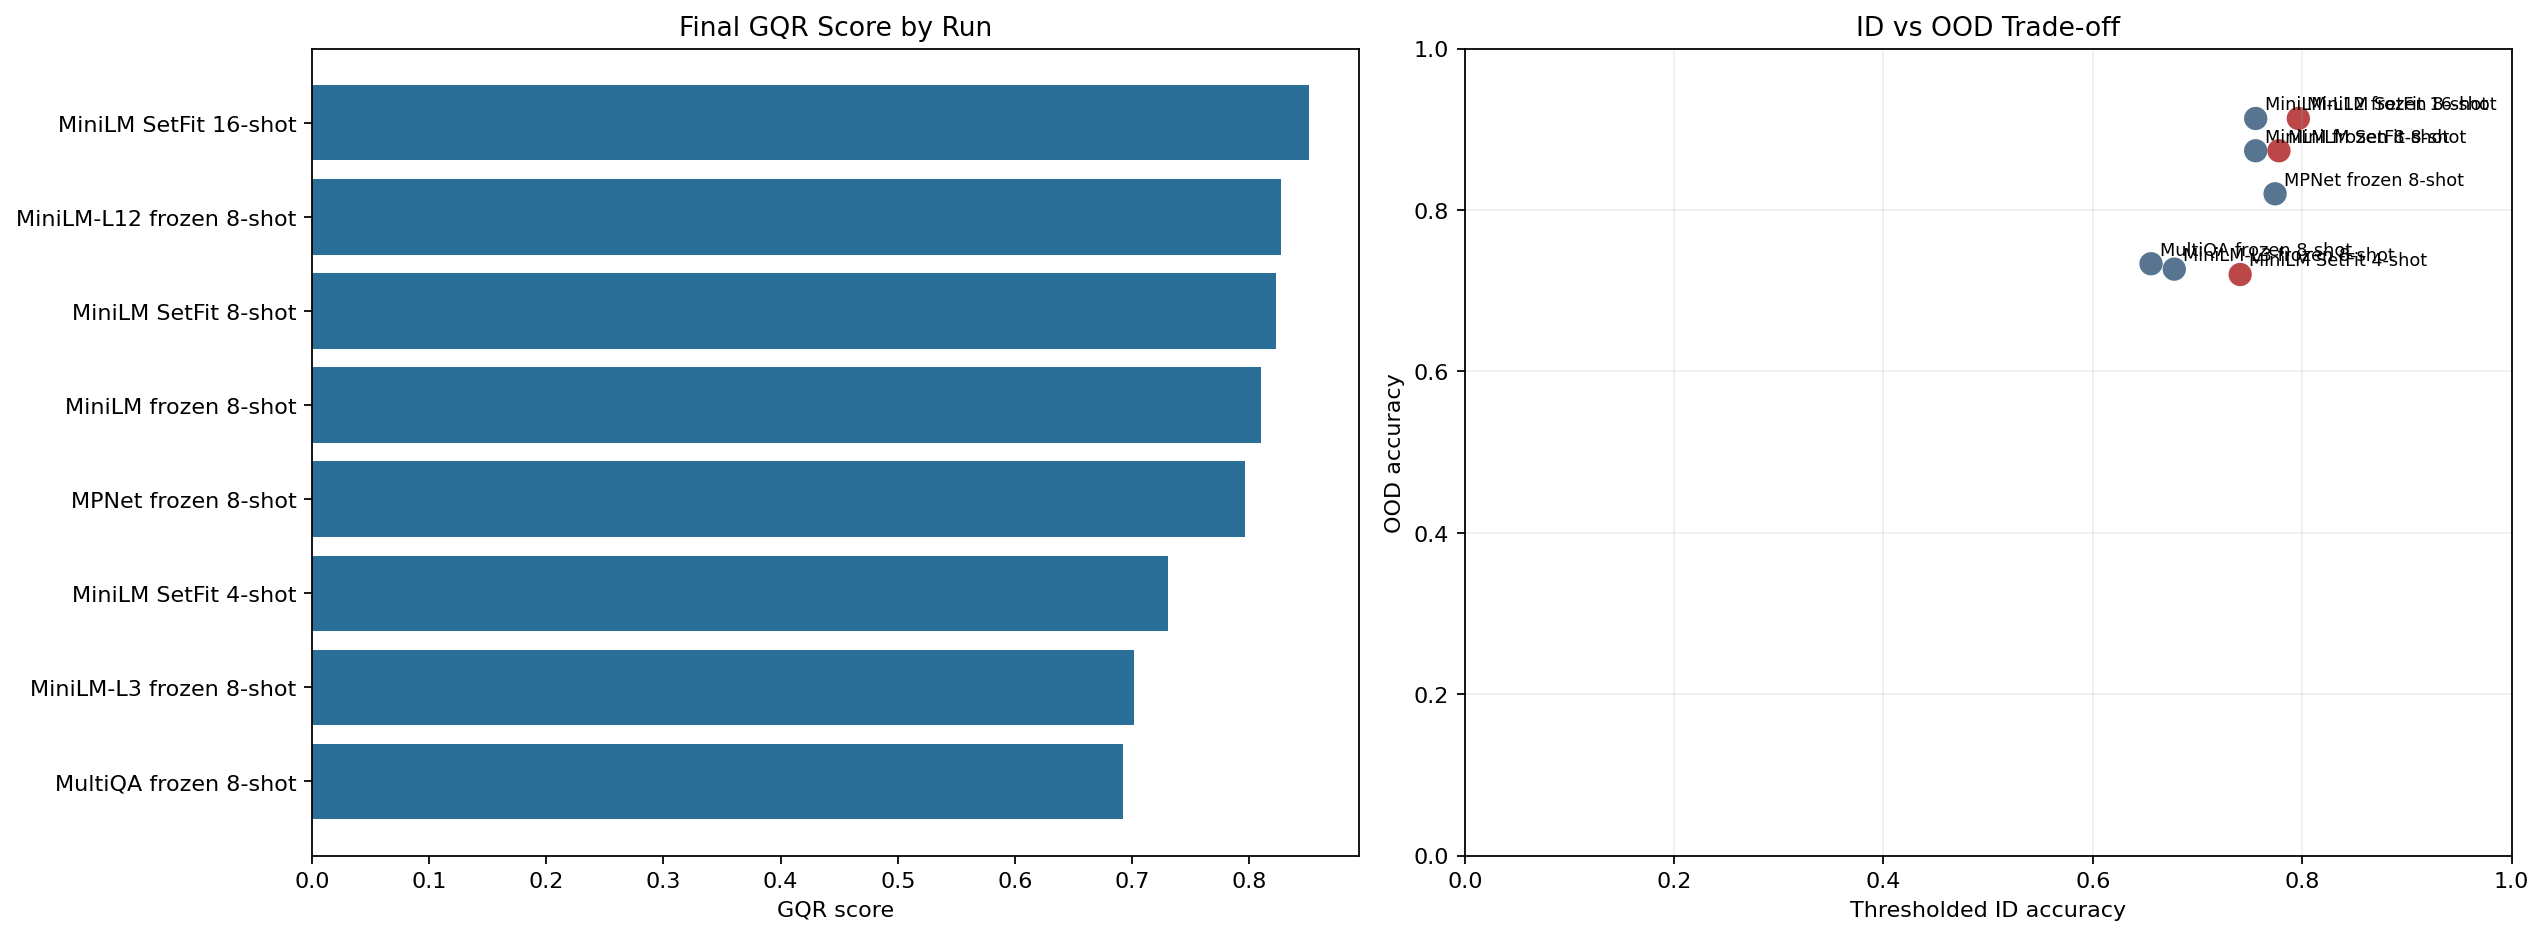

In [4]:
plot_df = benchmark_summary_df.copy()
plot_df["model_short"] = plot_df["embedding_model"].str.replace("sentence-transformers/", "", regex=False)
plot_df["tuning_label"] = np.where(plot_df["run_contrastive_fine_tuning"], "SetFit", "Frozen")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(plot_df["run_name"], plot_df["threshold_gqr_score"], color="#2a6f97")
axes[0].set_title("Final GQR Score by Run")
axes[0].set_xlabel("GQR score")
axes[0].invert_yaxis()

axes[1].scatter(
    plot_df["threshold_id_accuracy"],
    plot_df["threshold_ood_accuracy"],
    s=90,
    c=np.where(plot_df["run_contrastive_fine_tuning"], "#bc4749", "#577590"),
)
for _, row in plot_df.iterrows():
    axes[1].annotate(row["run_name"], (row["threshold_id_accuracy"], row["threshold_ood_accuracy"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set_title("ID vs OOD Trade-off")
axes[1].set_xlabel("Thresholded ID accuracy")
axes[1].set_ylabel("OOD accuracy")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(BENCHMARK_OUTPUT_DIR / "leaderboard_and_tradeoff.png", dpi=160, bbox_inches="tight")
plt.show()


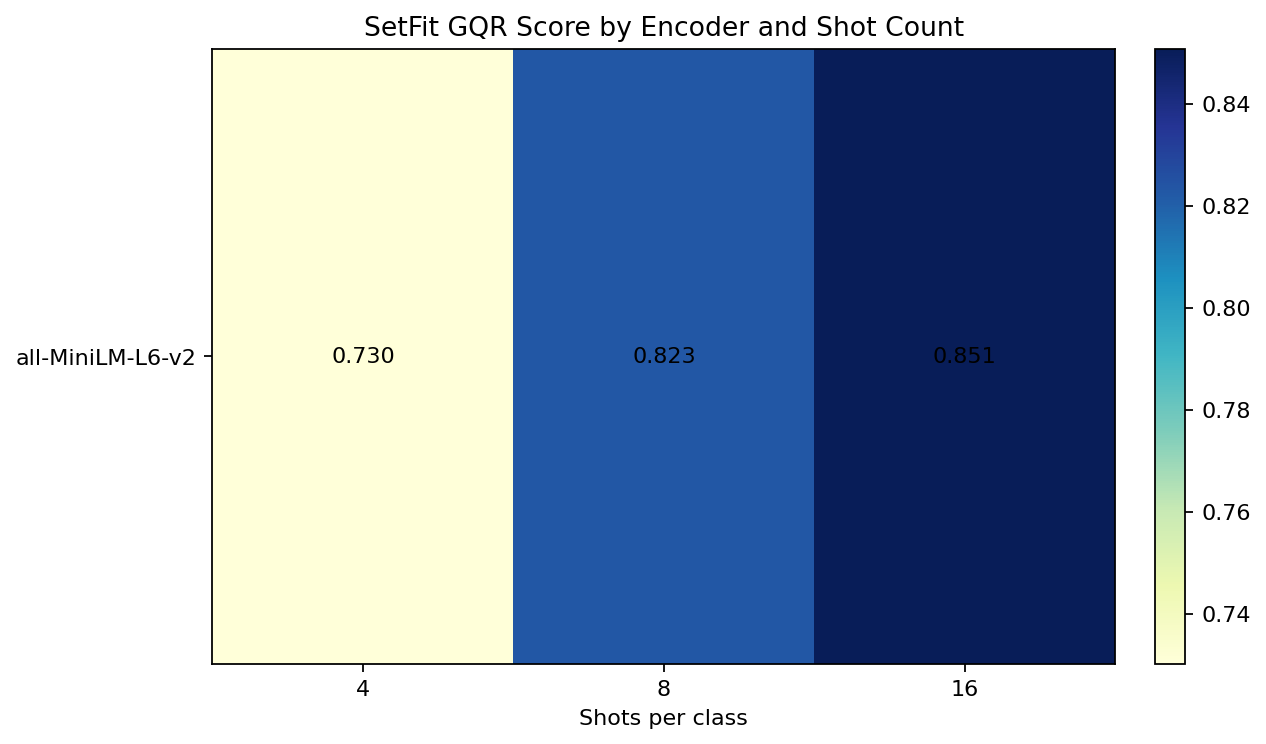

n_shots,model_short,4,8,16
0,all-MiniLM-L6-v2,0.730223,0.82279,0.850809


In [5]:
heatmap_df = benchmark_summary_df[benchmark_summary_df["run_contrastive_fine_tuning"]].copy()
heatmap_df["model_short"] = heatmap_df["embedding_model"].str.replace("sentence-transformers/", "", regex=False)
heatmap_table = heatmap_df.pivot_table(
    index="model_short",
    columns="n_shots",
    values="threshold_gqr_score",
    aggfunc="max",
)

fig, ax = plt.subplots(figsize=(8, 4.8))
image = ax.imshow(heatmap_table.to_numpy(), cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(len(heatmap_table.columns)))
ax.set_xticklabels(heatmap_table.columns.tolist())
ax.set_yticks(range(len(heatmap_table.index)))
ax.set_yticklabels(heatmap_table.index.tolist())
ax.set_xlabel("Shots per class")
ax.set_title("SetFit GQR Score by Encoder and Shot Count")
for row_index in range(len(heatmap_table.index)):
    for column_index in range(len(heatmap_table.columns)):
        value = heatmap_table.iloc[row_index, column_index]
        if not pd.isna(value):
            ax.text(column_index, row_index, f"{value:.3f}", ha="center", va="center", color="black")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(BENCHMARK_OUTPUT_DIR / "encoder_shot_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()
heatmap_table


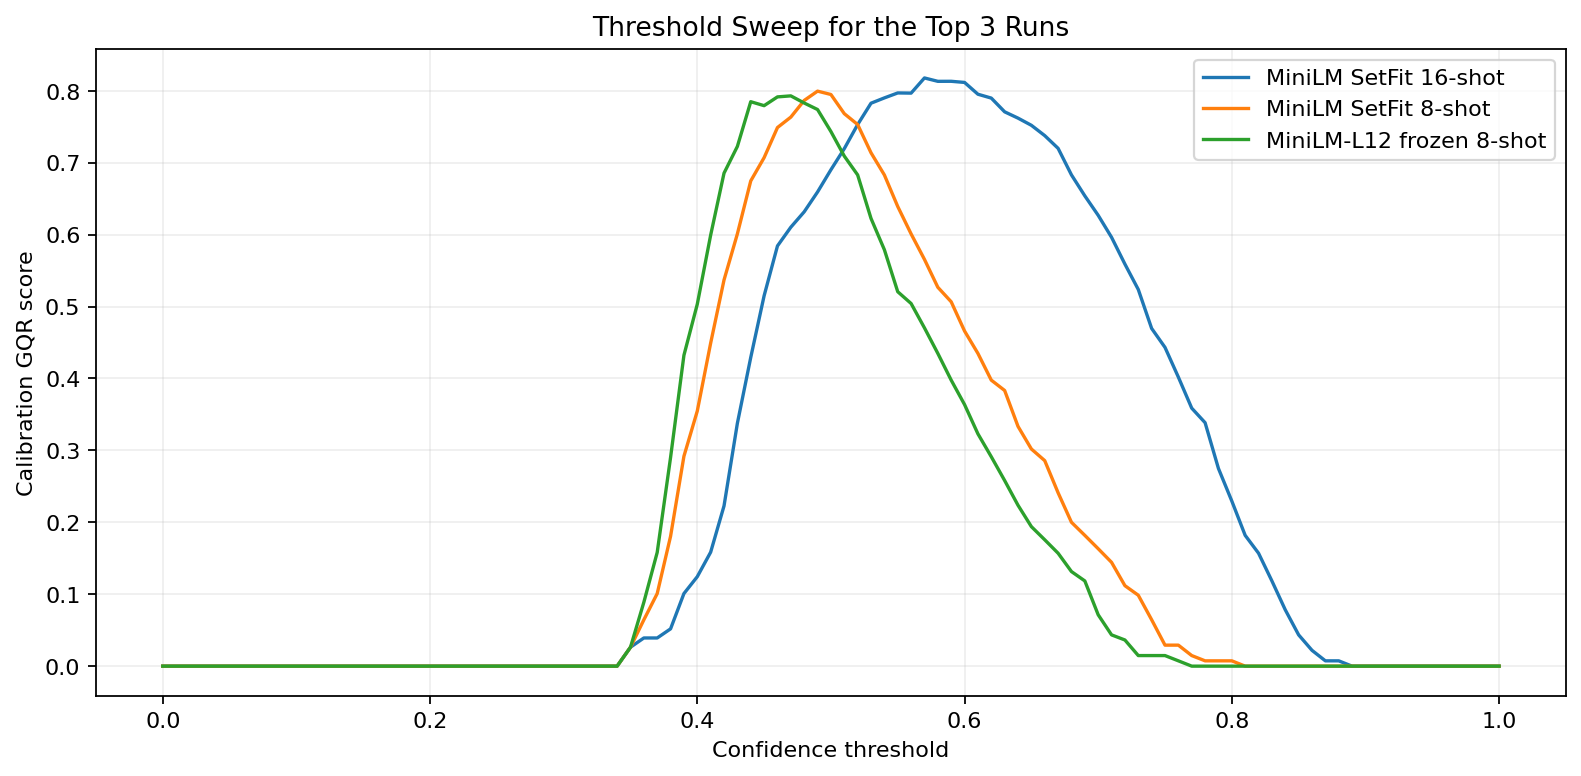

In [6]:
top_runs = benchmark_summary_df.head(3)["run_name"].tolist()
top_thresholds = benchmark_threshold_df[benchmark_threshold_df["run_name"].isin(top_runs)].copy()
top_thresholds = top_thresholds.sort_values(["run_name", "threshold"])

fig, ax = plt.subplots(figsize=(10, 5))
for run_name, group in top_thresholds.groupby("run_name"):
    ax.plot(group["threshold"], group["gqr_score"], label=run_name)
ax.set_title("Threshold Sweep for the Top 3 Runs")
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Calibration GQR score")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig(BENCHMARK_OUTPUT_DIR / "top_threshold_curves.png", dpi=160, bbox_inches="tight")
plt.show()


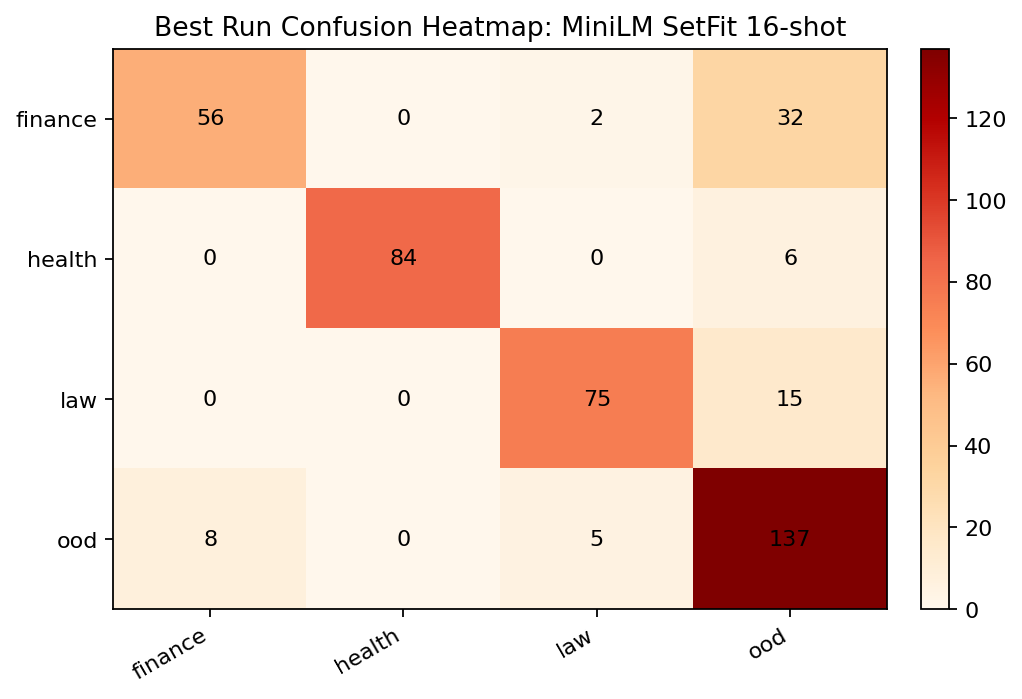

predicted_domain,true_domain,finance,health,law,ood
0,finance,56,0,2,32
1,health,0,84,0,6
2,law,0,0,75,15
3,ood,8,0,5,137


In [7]:
best_run_name = benchmark_summary_df.iloc[0]["run_name"]
best_confusion = benchmark_confusion_df[benchmark_confusion_df["run_name"] == best_run_name].copy()
best_confusion_pivot = best_confusion.pivot_table(
    index="true_domain",
    columns="predicted_domain",
    values="count",
    aggfunc="sum",
    fill_value=0,
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
image = ax.imshow(best_confusion_pivot.to_numpy(), cmap="OrRd", aspect="auto")
ax.set_xticks(range(len(best_confusion_pivot.columns)))
ax.set_xticklabels(best_confusion_pivot.columns.tolist(), rotation=30, ha="right")
ax.set_yticks(range(len(best_confusion_pivot.index)))
ax.set_yticklabels(best_confusion_pivot.index.tolist())
ax.set_title(f"Best Run Confusion Heatmap: {best_run_name}")
for row_index in range(len(best_confusion_pivot.index)):
    for column_index in range(len(best_confusion_pivot.columns)):
        ax.text(column_index, row_index, int(best_confusion_pivot.iloc[row_index, column_index]), ha="center", va="center", color="black")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(BENCHMARK_OUTPUT_DIR / "best_run_confusion_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()
best_confusion_pivot


### Saved Benchmark Snapshot

The benchmark artifacts currently saved under `artifacts/setfit_router/benchmark` were produced on this machine with the public fallback train split and the built-in OOD fallback, using a separate calibration split for threshold selection.

| Run | Forced ID Acc. | Threshold ID Acc. | OOD Acc. | GQR | Time (s) |
| --- | ---: | ---: | ---: | ---: | ---: |
| MiniLM SetFit 16-shot | 0.9556 | 0.7963 | 0.9133 | 0.8508 | 87.30 |
| MiniLM-L12 frozen 8-shot | 0.9370 | 0.7556 | 0.9133 | 0.8270 | 20.65 |
| MiniLM SetFit 8-shot | 0.9407 | 0.7778 | 0.8733 | 0.8228 | 88.00 |
| MiniLM frozen 8-shot | 0.9370 | 0.7556 | 0.8733 | 0.8102 | 12.90 |
| MPNet frozen 8-shot | 0.9593 | 0.7741 | 0.8200 | 0.7964 | 97.73 |
| MiniLM SetFit 4-shot | 0.9111 | 0.7407 | 0.7200 | 0.7302 | 78.15 |
| MiniLM-L3 frozen 8-shot | 0.9185 | 0.6778 | 0.7267 | 0.7014 | 8.92 |
| MultiQA frozen 8-shot | 0.9259 | 0.6556 | 0.7333 | 0.6923 | 18.32 |

Takeaways:
- `MiniLM SetFit 16-shot` is the current best saved run and gives the strongest balanced GQR score.
- `MiniLM-L12 frozen 8-shot` is an interesting result because it beats several more expensive alternatives without any contrastive fine-tuning.
- The encoder family matters: `MiniLM-L3` and `MultiQA` were notably weaker than `MiniLM-L6`, `MiniLM-L12`, and `MPNet` on this router task.
- More shots still helped the SetFit runs, especially moving from `4-shot` to `16-shot`.
- Full `MPNet SetFit` fine-tuning was attempted earlier but ran out of CPU memory, so it is documented as a practical limitation rather than a final scored run.


## 16. Compare Against The Full-Data Baseline

The benchmark above compares few-shot variants against each other. This section adds the project's saved full-data baseline router so we can see whether SetFit few-shot training is merely competitive within the few-shot setting or whether it actually closes the gap to the original baseline.

To keep the comparison fair, the baseline artifact is evaluated on the same benchmark report split used by the SetFit section. That gives us one shared table and one shared plot.


In [8]:
from router.metrics import evaluate_router
from router.model import DomainRouter
from router.setfit_experiments import split_calibration_report_frames

baseline_router_dir = PROJECT_ROOT / "artifacts" / "router"
baseline_router = DomainRouter.load(baseline_router_dir)

_, benchmark_report_df = split_calibration_report_frames(
    valid_df=benchmark_valid_df,
    ood_df=benchmark_ood_df,
    calibration_fraction=BENCHMARK_CALIBRATION_FRACTION,
    seed=SEED,
)

baseline_predictions = baseline_router.predict(
    benchmark_report_df["text"].tolist(),
    batch_size=64,
)
baseline_scores = evaluate_router(
    benchmark_report_df["label"].tolist(),
    baseline_predictions,
)

baseline_comparison_row = pd.DataFrame(
    [
        {
            "run_name": "Full-data baseline",
            "embedding_model": str(baseline_router.embedding_model),
            "n_shots": "full train",
            "run_contrastive_fine_tuning": False,
            "forced_id_accuracy": np.nan,
            "threshold_id_accuracy": baseline_scores.id_accuracy,
            "threshold_ood_accuracy": baseline_scores.ood_accuracy,
            "threshold_gqr_score": baseline_scores.gqr_score,
            "best_threshold": baseline_router.threshold,
            "total_seconds": np.nan,
            "comparison_note": "trained on full baseline dataset",
        }
    ]
)

baseline_comparison_row


,run_name,embedding_model,n_shots,run_contrastive_fine_tuning,threshold_id_accuracy,threshold_ood_accuracy,threshold_gqr_score,best_threshold,comparison_note
4,Full-data baseline,c:\Users\jurko\nsiete\NSIETE_2026\nsiete_projekt3\artifacts\router\embedding_model,full train,False,0.948148,0.686667,0.796496,0.890543,trained on full baseline dataset


In [9]:
comparison_table = pd.concat(
    [baseline_comparison_row, benchmark_summary_df],
    ignore_index=True,
    sort=False,
).copy()

comparison_table = comparison_table[
    [
        "run_name",
        "embedding_model",
        "n_shots",
        "run_contrastive_fine_tuning",
        "threshold_id_accuracy",
        "threshold_ood_accuracy",
        "threshold_gqr_score",
        "best_threshold",
        "comparison_note",
    ]
]

comparison_table = comparison_table.sort_values("threshold_gqr_score", ascending=False).reset_index(drop=True)
comparison_table


,run_name,embedding_model,n_shots,run_contrastive_fine_tuning,threshold_id_accuracy,threshold_ood_accuracy,threshold_gqr_score,best_threshold,comparison_note
0,MiniLM SetFit 16-shot,sentence-transformers/all-MiniLM-L6-v2,16,True,0.796296,0.913333,0.850809,0.570000,NaN
1,MiniLM-L12 frozen 8-shot,sentence-transformers/all-MiniLM-L12-v2,8,False,0.755556,0.913333,0.826986,0.470000,NaN
2,MiniLM SetFit 8-shot,sentence-transformers/all-MiniLM-L6-v2,8,True,0.777778,0.873333,0.822790,0.490000,NaN
3,MiniLM frozen 8-shot,sentence-transformers/all-MiniLM-L6-v2,8,False,0.755556,0.873333,0.810186,0.460000,NaN
4,Full-data baseline,c:\Users\jurko\nsiete\NSIETE_2026\nsiete_projekt3\artifacts\router\embedding_model,full train,False,0.948148,0.686667,0.796496,0.890543,trained on full baseline dataset
5,MPNet frozen 8-shot,sentence-transformers/paraphrase-mpnet-base-v2,8,False,0.774074,0.820000,0.796375,0.510000,NaN
6,MiniLM SetFit 4-shot,sentence-transformers/all-MiniLM-L6-v2,4,True,0.740741,0.720000,0.730223,0.430000,NaN
7,MiniLM-L3 frozen 8-shot,sentence-transformers/paraphrase-MiniLM-L3-v2,8,False,0.677778,0.726667,0.701371,0.500000,NaN
8,MultiQA frozen 8-shot,sentence-transformers/multi-qa-MiniLM-L6-cos-v1,8,False,0.655556,0.733333,0.692267,0.490000,NaN


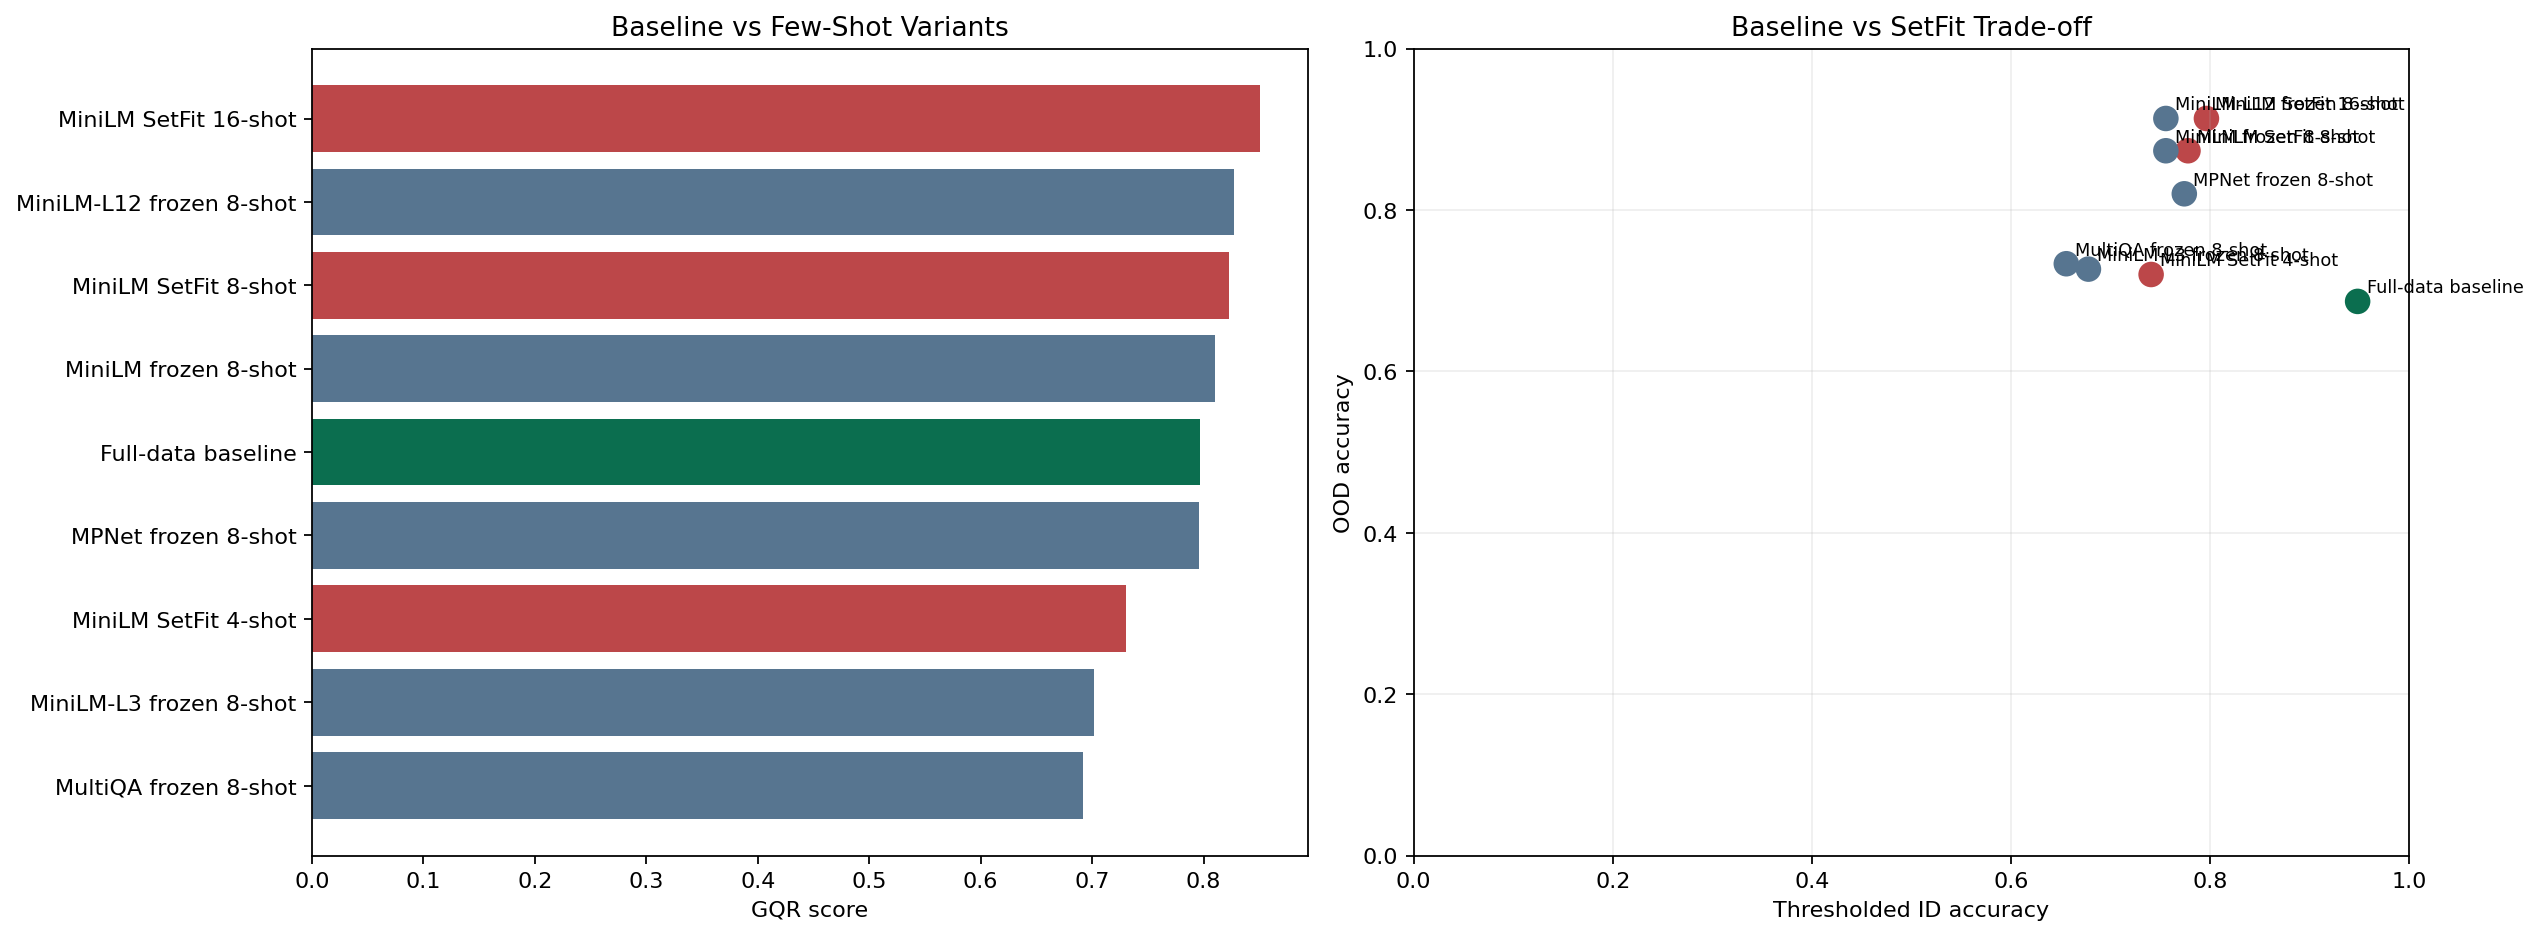

In [10]:
plot_table = comparison_table.copy()
plot_table["color"] = np.where(
    plot_table["run_name"].eq("Full-data baseline"),
    "#0b6e4f",
    np.where(plot_table["run_contrastive_fine_tuning"], "#bc4749", "#577590"),
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(plot_table["run_name"], plot_table["threshold_gqr_score"], color=plot_table["color"])
axes[0].set_title("Baseline vs Few-Shot Variants")
axes[0].set_xlabel("GQR score")
axes[0].invert_yaxis()

axes[1].scatter(
    plot_table["threshold_id_accuracy"],
    plot_table["threshold_ood_accuracy"],
    s=110,
    c=plot_table["color"],
)
for _, row in plot_table.iterrows():
    axes[1].annotate(row["run_name"], (row["threshold_id_accuracy"], row["threshold_ood_accuracy"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set_title("Baseline vs SetFit Trade-off")
axes[1].set_xlabel("Thresholded ID accuracy")
axes[1].set_ylabel("OOD accuracy")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(BENCHMARK_OUTPUT_DIR / "baseline_vs_setfit.png", dpi=160, bbox_inches="tight")
plt.show()


The comparison plot answers a different question than the few-shot benchmark alone. In this saved run, the full-data baseline keeps much higher in-domain accuracy, but `MiniLM SetFit 16-shot` achieves a better balanced GQR score because its OOD rejection is much stronger on the shared benchmark report split.


This expanded section gives you several stronger discussion angles for the assignment: whether SetFit helps over a frozen encoder, whether more shots are worth the extra cost, which encoder offers the best trade-off, and how threshold calibration changes the final routing behavior.
